# 15 — Overlay: BUY/SELL signals on price + how each was decided

Auto-picks the most-signalled symbols (tickers and theme ETFs together). For
each it draws the price line with BUY/SELL markers - clusters of nearby
same-direction signals merge into one big HIGH CONVICTION arrow - and prints
the reasoning behind every signal.

**How a signal is decided** (notebook 10): a conviction score 0-5 from a
*conjunctive* gate - an attention take-off (`att_z`) AND a sentiment change
(`sent_5d_chg`) must agree, combined into `conv_z`. BUY needs score >= 4,
SELL >= 3. The `reason` column spells out each factor for that specific call.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py, including its
# --start/--end overrides) win; otherwise fall back to the constants at the
# top of update_data.py. Same toggle as live vs backtest either way.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    # daily close, then made CONTINUOUS (forward-fill weekends/holidays) so the
    # line is smooth with no gaps. Clip to the window.
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)


# --- x-axis tick control (X_TICKS in the parameters cell) ---
# 'auto' = matplotlib decides; 'W' = a label every week; 'M' = every month.
# Weekly labels are only readable on windows up to ~6 months - use
# PLOT_LAST_DAYS to zoom in first.
import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2019-01-01 -> 2020-01-01


In [2]:
HOW_MANY = 6
FREQ = 'W'        # 'W' weekly (smooth price line), 'D' daily, 'M' monthly
X_TICKS = 'auto'  # x-axis labels: 'auto', 'W' (weekly), 'M' (monthly)
PLOT_LAST_DAYS = None   # e.g. 120 = zoom to the last 120 days (None = whole window)
# --- high-conviction clustering: several same-direction signals close together
# on one symbol are ONE conviction event, not several trades ---
CLUSTER_DAYS = 10  # same-side signals within this many days merge into a cluster
CONV_MIN     = 2   # a cluster needs at least this many signals to count as
                   # HIGH CONVICTION (big arrow on the charts)
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', 200)

auto signalled symbols: ['GME', 'SMH', 'JPM', 'IGV', 'DIS', 'JETS']

GME: 17 signals - how each was decided
action_date action  score     att_z    conv_z  sent_5d_chg                                                                                                                                                                                                   reason
 2019-01-10   SELL      3  1.684302 -0.936003    -0.555556                                                     SELL GME: mood deteriorating (5d sentiment -0.556 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2019-01-11   SELL      3  1.332506 -0.548417    -0.127273                                                     SELL GME: mood deteriorating (5d sentiment -0.127 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2019-03-28   SELL      3  2.549799 -1.029734    -0.183333                                             SELL GME:

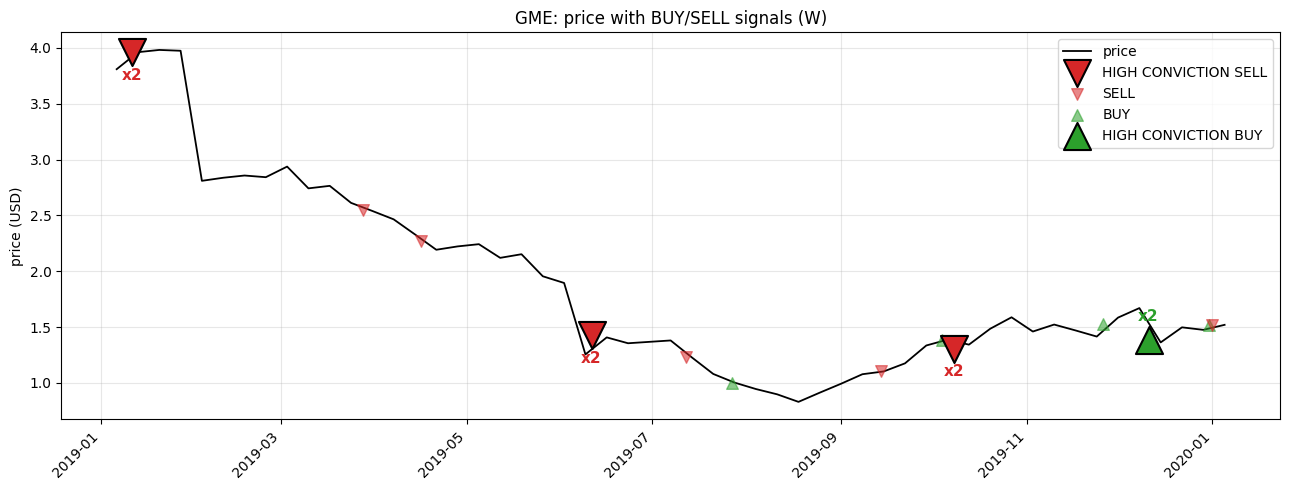


SMH: 15 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                  reason
 2019-01-09   SELL      3 0.483284 -4.305225    -0.111111                                      SELL SMH: mood deteriorating (5d sentiment -0.111 < 0) + crowd leaning bearish (conviction z -4.31 < -2.0) + Reddit AND X both rising -> score 3/5
 2019-01-10   SELL      3 1.029218 -1.856185    -0.317460                                    SELL SMH: mood deteriorating (5d sentiment -0.317 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2019-01-29   SELL      3 1.151509  0.831322    -0.266667                                    SELL SMH: mood deteriorating (5d sentiment -0.267 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> sc

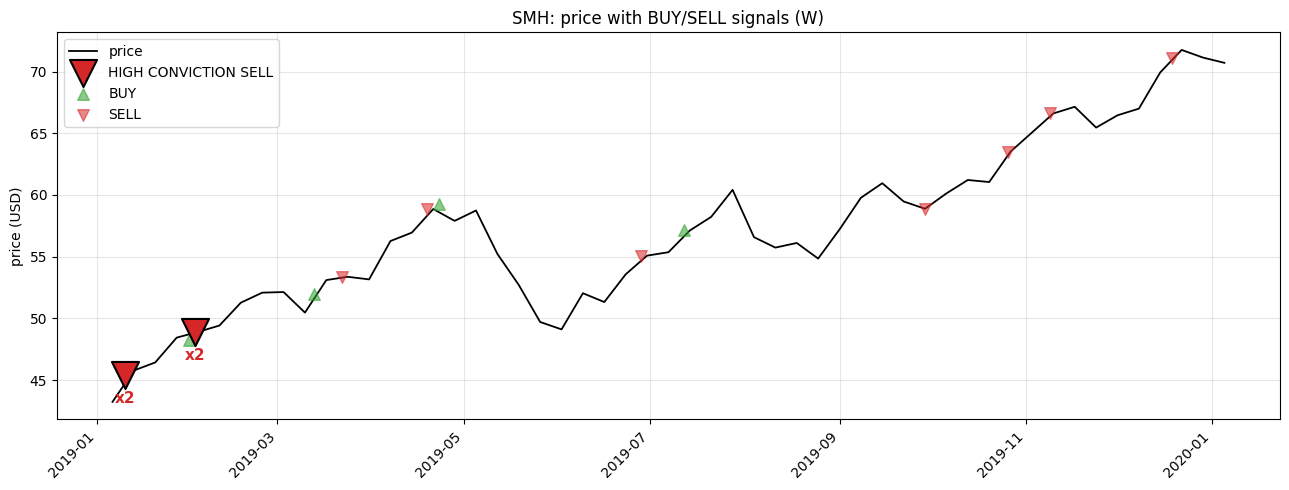


JPM: 13 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                  reason
 2019-01-16   SELL      4 2.324300 -1.062009    -0.222222 SELL JPM: attention surged (z +2.32 > 2.0) + mood deteriorating (5d sentiment -0.222 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
 2019-03-27   SELL      3 1.818943  0.346141    -0.400000                                    SELL JPM: mood deteriorating (5d sentiment -0.400 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2019-04-15    BUY      4 2.130536  0.837782     0.309524                                   BUY JPM: attention surged (z +2.13 > 2.0) + mood improving (5d sentiment +0.310 > 0) + no crowded-top warning + Reddit AND X both rising -> sc

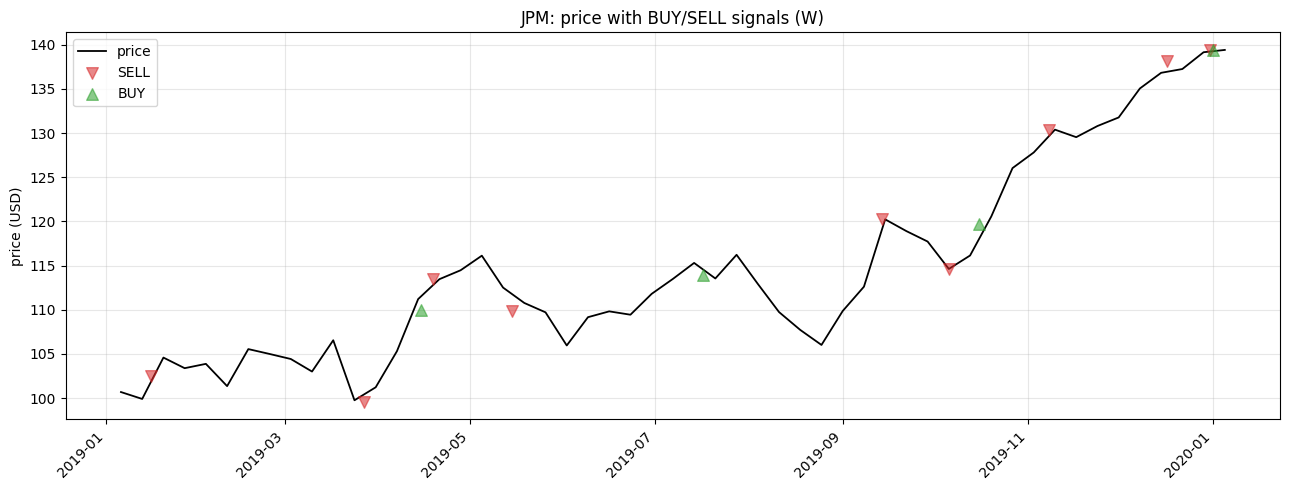


IGV: 12 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                                   reason
 2019-01-09   SELL      3 1.125913  0.660951    -0.266667                                                     SELL IGV: mood deteriorating (5d sentiment -0.267 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2019-02-14    BUY      4 2.036807  0.732474     0.466667                                                    BUY IGV: attention surged (z +2.04 > 2.0) + mood improving (5d sentiment +0.467 > 0) + no crowded-top warning + Reddit AND X both rising -> score 4/5
 2019-03-06   SELL      3 1.773082  0.126855    -0.333333                                                     SELL IGV: mood deteriorating (5d sentiment -0.333 < 0) + crowded-top dive

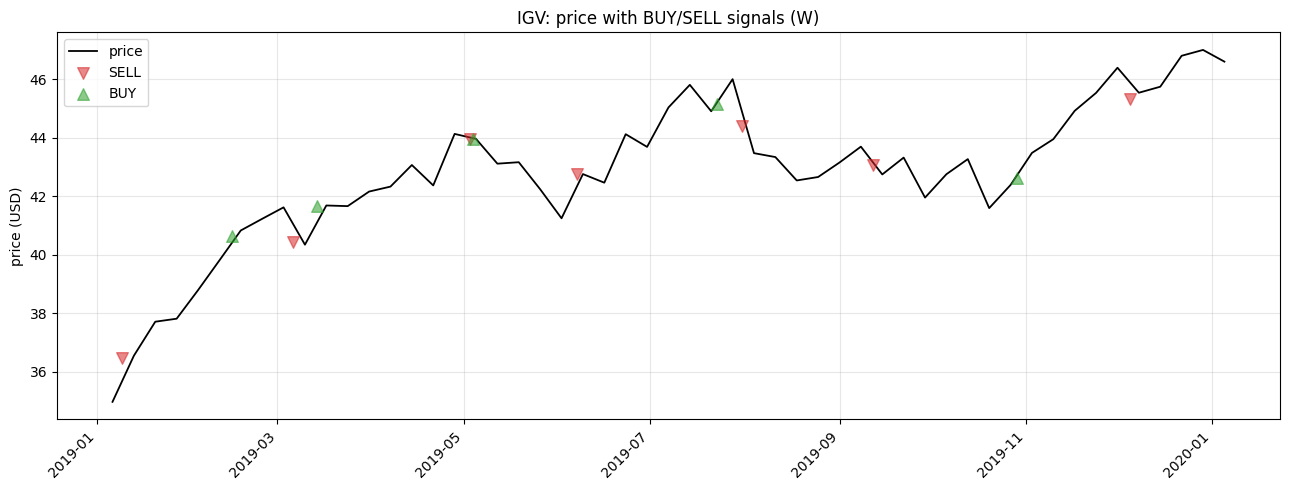


DIS: 12 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                  reason
 2019-02-05    BUY      4 2.221779  0.643205     0.466667                                   BUY DIS: attention surged (z +2.22 > 2.0) + mood improving (5d sentiment +0.467 > 0) + no crowded-top warning + Reddit AND X both rising -> score 4/5
 2019-02-10   SELL      4 3.026943  1.465750    -0.266667 SELL DIS: attention surged (z +3.03 > 2.0) + mood deteriorating (5d sentiment -0.267 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
 2019-03-22    BUY      4 1.973529  2.976060     0.977778                   BUY DIS: mood improving (5d sentiment +0.978 > 0) + crowd leaning bullish (conviction z +2.98 > 2.0) + no crowded-top warning + Reddit AND X both rising -> sc

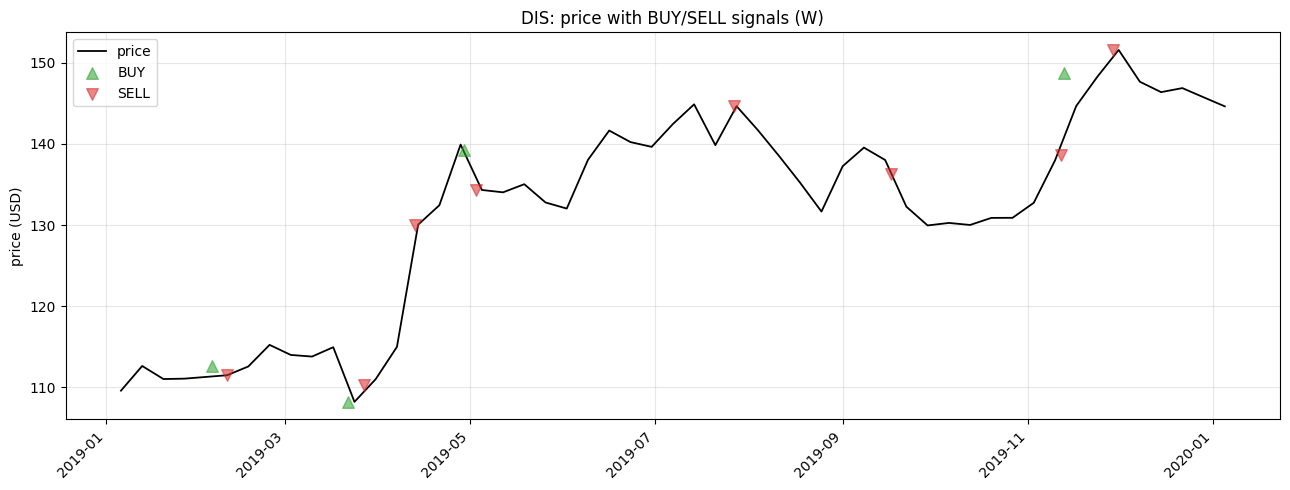


JETS: 10 signals - how each was decided
action_date action  score     att_z    conv_z  sent_5d_chg                                                                                                                                                                 reason
 2019-02-11   SELL      3  1.036930  0.266443    -0.666667                  SELL JETS: mood deteriorating (5d sentiment -0.667 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2019-02-22    BUY      4 -0.069781  2.527985     1.000000 BUY JETS: mood improving (5d sentiment +1.000 > 0) + crowd leaning bullish (conviction z +2.53 > 2.0) + no crowded-top warning + Reddit AND X both rising -> score 4/5
 2019-03-02   SELL      3  1.573596 -0.790405    -1.000000                  SELL JETS: mood deteriorating (5d sentiment -1.000 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2019-03-14    BUY      4  1.314021  2.688892     1.000

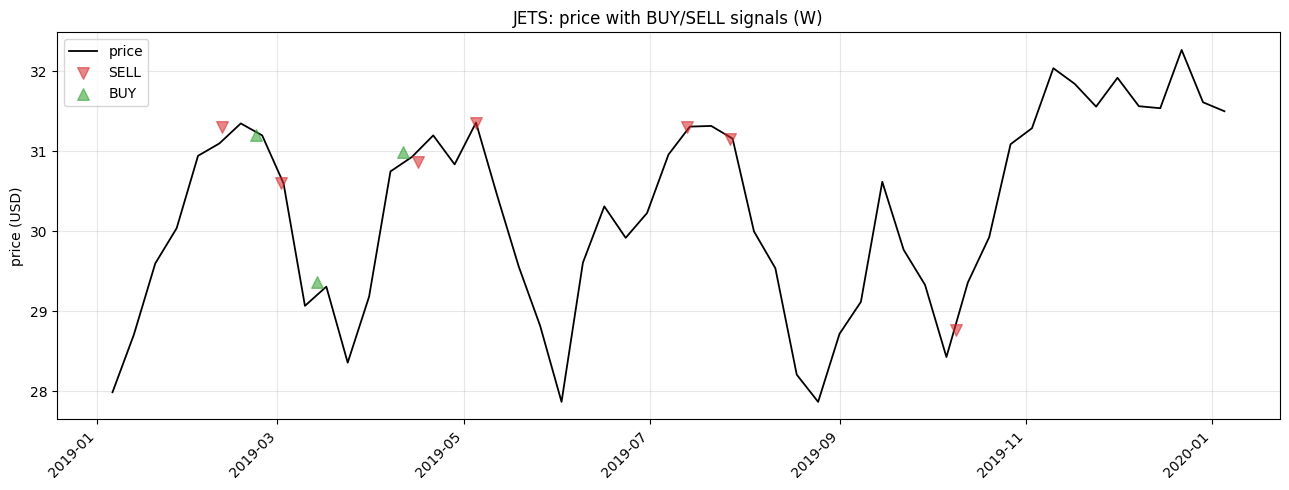

In [3]:
tick = pd.read_parquet(os.path.join(P, 'trade_signals_tickers.parquet'))
theme = pd.read_parquet(os.path.join(P, 'trade_signals.parquet'))
tick['action_date'] = pd.to_datetime(tick['action_date']); theme['action_date'] = pd.to_datetime(theme['action_date'])
tick = clip_dates(tick, 'action_date'); theme = clip_dates(theme, 'action_date')
if PLOT_LAST_DAYS and (len(tick) or len(theme)):     # zoom: recent stretch only
    newest = max([d for d in [tick['action_date'].max(), theme['action_date'].max()] if pd.notna(d)])
    WIN_LO = max(WIN_LO, newest - pd.Timedelta(days=PLOT_LAST_DAYS))
    tick = tick[tick['action_date'] >= WIN_LO]; theme = theme[theme['action_date'] >= WIN_LO]

# unify both signal files, carrying the decision detail
DET = ['action_date', 'action', 'score', 'att_z', 'conv_z', 'sent_5d_chg', 'reason']
tk = tick.rename(columns={'ticker': 'symbol'})[['symbol'] + DET]
th = theme.rename(columns={'etf': 'symbol'})[['symbol'] + DET]
sig_all = pd.concat([tk, th], ignore_index=True)
symbols = sig_all['symbol'].value_counts().head(HOW_MANY).index.tolist()
print('auto signalled symbols:', symbols)

prices = load_prices()

def cluster_signals(one_symbol_df, max_gap_days=CLUSTER_DAYS):
    """Group SAME-SIDE signals whose neighbour is within max_gap_days.
    Several signals close together = the model repeating itself = one
    HIGH-CONVICTION event, not several separate trades."""
    clusters = []
    for side in ('BUY', 'SELL'):
        rows = one_symbol_df[one_symbol_df['action'] == side].sort_values('action_date')
        dates = list(rows['action_date'])
        if not dates:
            continue
        cur = [dates[0]]
        for dt in dates[1:]:
            if (dt - cur[-1]).days <= max_gap_days:
                cur.append(dt)
            else:
                clusters.append({'side': side, 'dates': cur, 'n': len(cur),
                                 'start': cur[0], 'end': cur[-1]})
                cur = [dt]
        clusters.append({'side': side, 'dates': cur, 'n': len(cur),
                         'start': cur[0], 'end': cur[-1]})
    return sorted(clusters, key=lambda c: c['start'])

for symbol in symbols:
    px_daily = price_series(prices, symbol)
    if px_daily.empty:
        print('skip', symbol, '- no price rows in this window - re-run pull_bloomberg_prices.py (it pulls every signalled symbol)'); continue
    s = sig_all[sig_all['symbol'] == symbol].sort_values('action_date').copy()
    s['price'] = s['action_date'].map(px_daily)     # marker height from the daily price

    # --- the decision detail for this symbol ---
    print('\n' + '=' * 90)
    print(f'{symbol}: {len(s)} signals - how each was decided')
    print('=' * 90)
    print(s[DET].to_string(index=False))

    # --- the chart: singles = small faded markers; clusters (>= CONV_MIN
    #     signals close together) = one big arrow sized by the pile-on ---
    px_line = px_daily if FREQ == 'D' else px_daily.resample(FREQ).last()
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(px_line.index, px_line.values, color='black', linewidth=1.3, label='price')
    clusters = cluster_signals(s)
    done_labels = set()
    for cl in clusters:
        mid = cl['dates'][len(cl['dates']) // 2]           # middle of the cluster
        price_at = px_daily.asof(mid)
        if pd.isna(price_at):
            continue
        color = 'tab:green' if cl['side'] == 'BUY' else 'tab:red'
        marker = '^' if cl['side'] == 'BUY' else 'v'
        if cl['n'] >= CONV_MIN:
            size = min(200 + 180 * (cl['n'] - CONV_MIN + 1), 900)
            label = f"HIGH CONVICTION {cl['side']}" if f"hc{cl['side']}" not in done_labels else None
            done_labels.add(f"hc{cl['side']}")
            ax.scatter([mid], [price_at], marker=marker, s=size, color=color,
                       edgecolors='black', linewidths=1.5, zorder=6, label=label)
            ax.annotate(f"x{cl['n']}", (mid, price_at), textcoords='offset points',
                        xytext=(0, 14 if cl['side'] == 'BUY' else -20),
                        fontsize=11, fontweight='bold', ha='center', color=color)
        else:
            label = cl['side'] if cl['side'] not in done_labels else None
            done_labels.add(cl['side'])
            ax.scatter([mid], [price_at], marker=marker, s=70, color=color,
                       alpha=0.55, zorder=5, label=label)
    ax.set_ylabel('price (USD)'); ax.set_title(f'{symbol}: price with BUY/SELL signals ({FREQ})')
    set_date_ticks(ax, X_TICKS)
    ax.legend(); ax.grid(True, alpha=0.3); fig.tight_layout(); plt.show()

## Signal report card — does the model work?

Three views over EVERY signal in the window (not just the top symbols above):

1. **Forward returns** — average price move 5/10/20 days AFTER acting on a
   signal. BUYs should skew positive, SELLs negative. This is the visual
   check: change the window in `update_data.py`, re-run, and compare eras.
2. **Score vs outcome** — do 5/5-score signals really beat 4/5? If yes,
   raising `MIN_SCORE` in notebook 10 is free selectivity.
3. **Signal frequency** — how many calls per week the model makes. Spikes =
   hot regimes; a flood of signals is a reason to tighten the knobs.

242 signals with price data (of 271 total)
BUY :  98 signals | 10d hit rate   66% | avg 10d return +1.04%
SELL: 135 signals | 10d hit rate   42% | avg 10d return +0.43%


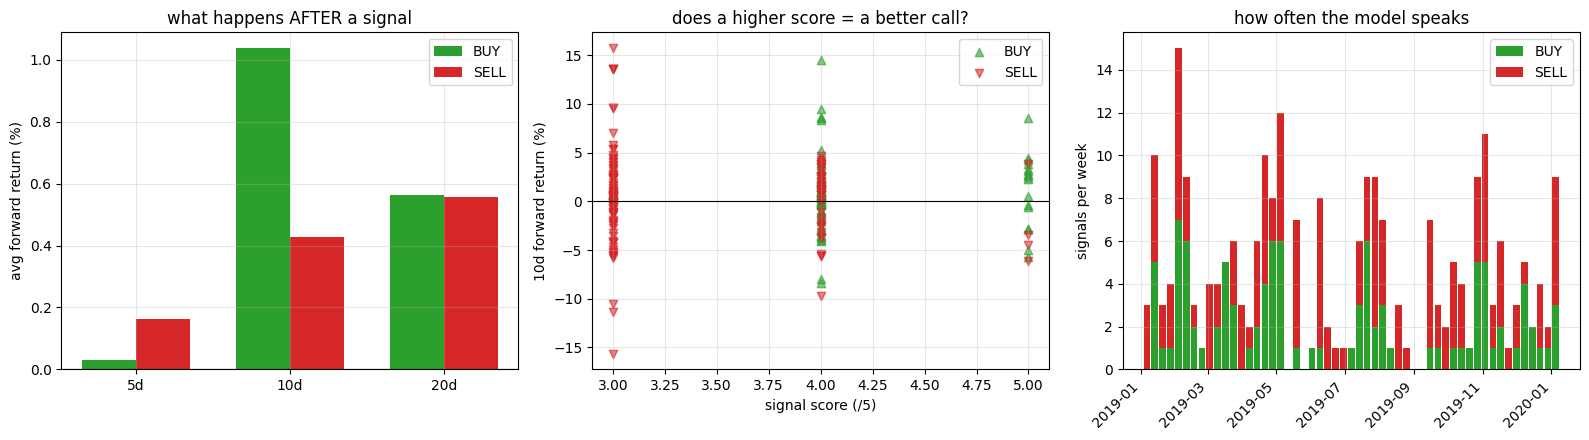

In [4]:
# ==== SIGNAL REPORT CARD ====
HORIZONS = [5, 10, 20]          # trading-day-ish horizons (calendar days, ffilled)

# price series once per symbol (they are ffilled daily, so .asof works cleanly)
px_cache = {sym: price_series(prices, sym) for sym in sig_all['symbol'].unique()}

rows = []
for _, s in sig_all.iterrows():
    px = px_cache.get(s['symbol'], pd.Series(dtype=float))
    if px.empty:
        continue
    p0 = px.asof(s['action_date'])
    if pd.isna(p0):
        continue
    row = {'symbol': s['symbol'], 'action': s['action'],
           'score': int(s['score']), 'action_date': s['action_date']}
    for h in HORIZONS:
        p1 = px.asof(s['action_date'] + pd.Timedelta(days=h))
        # signals too close to the end of the data have no forward price yet
        row[f'ret_{h}d'] = (p1 / p0 - 1) * 100 if pd.notna(p1) and p1 != p0 else None
    rows.append(row)
perf = pd.DataFrame(rows)
print(f'{len(perf)} signals with price data (of {len(sig_all)} total)')

if len(perf):
    # --- hit rate: BUYs that went up, SELLs that went down (10d horizon) ---
    for side, good in [('BUY', 1), ('SELL', -1)]:
        r = perf[perf['action'] == side]['ret_10d'].dropna()
        if len(r):
            hits = (r * good > 0).mean() * 100
            print(f'{side:<4}: {len(r):>3} signals | 10d hit rate {hits:4.0f}% '
                  f'| avg 10d return {r.mean():+.2f}%')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. average forward return by side and horizon
    ax = axes[0]
    width = 0.35
    xs = range(len(HORIZONS))
    for off, (side, color) in enumerate([('BUY', 'tab:green'), ('SELL', 'tab:red')]):
        means = [perf[perf['action'] == side][f'ret_{h}d'].mean() for h in HORIZONS]
        ax.bar([x + off * width for x in xs], means, width, label=side, color=color)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks([x + width / 2 for x in xs])
    ax.set_xticklabels([f'{h}d' for h in HORIZONS])
    ax.set_ylabel('avg forward return (%)')
    ax.set_title('what happens AFTER a signal')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 2. score vs 10-day outcome
    ax = axes[1]
    for side, color, marker in [('BUY', 'tab:green', '^'), ('SELL', 'tab:red', 'v')]:
        sub = perf[perf['action'] == side].dropna(subset=['ret_10d'])
        ax.scatter(sub['score'], sub['ret_10d'], color=color, marker=marker,
                   alpha=0.6, label=side)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('signal score (/5)'); ax.set_ylabel('10d forward return (%)')
    ax.set_title('does a higher score = a better call?')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 3. signals per week over time
    ax = axes[2]
    weekly = (perf.set_index('action_date').groupby('action')
              .resample('W').size().unstack(0, fill_value=0) if len(perf) else None)
    if weekly is not None and len(weekly):
        if 'BUY' in weekly:
            ax.bar(weekly.index, weekly['BUY'], width=6, color='tab:green', label='BUY')
        if 'SELL' in weekly:
            ax.bar(weekly.index, weekly.get('SELL', 0), width=6, color='tab:red',
                   bottom=weekly.get('BUY', 0), label='SELL')
    ax.set_ylabel('signals per week'); ax.set_title('how often the model speaks')
    set_date_ticks(ax, X_TICKS)
    ax.legend(); ax.grid(True, alpha=0.3)

    fig.tight_layout(); plt.show()
else:
    print('no signals with price coverage in this window - '
          'run update_data.py / pull_bloomberg_prices.py first')

## The 1-week lookback — the live trading table

This is the primary trading metric. For every theme, compare the
**last 7 days** against the 7 days before:

- `velocity_chg` — mentions last 7d minus prior 7d (is attention accelerating?)
- `conv_now` — latest conviction_z (the 7-day bull-pressure z from notebook 09)
- `conv_chg_7d` — conviction now minus one week ago (is the crowd getting MORE convinced?)

Big positive `velocity_chg` + rising `conv_chg_7d` = the setup the BUY signals look for.

1-WEEK LOOKBACK (data through 2020-01-01) - sorted by attention change
                     mentions_7d  mentions_prior7d  velocity_chg  conv_now  conv_week_ago  conv_chg_7d
theme                                                                                                 
consumer_retail              754             586.0         168.0      0.11          -0.17         0.28
china_geopolitics            487             335.0         152.0      0.10           1.00        -0.90
real_estate                  348             236.0         112.0     -0.90          -0.04        -0.86
fintech_payments             327             245.0          82.0     -0.46           0.02        -0.48
ev_clean_energy             1550            1478.0          72.0      1.44           1.60        -0.16
financials                   714             643.0          71.0     -0.08          -0.58         0.50
rates_bonds                  282             259.0          23.0      0.38          -0.19         0.57
go

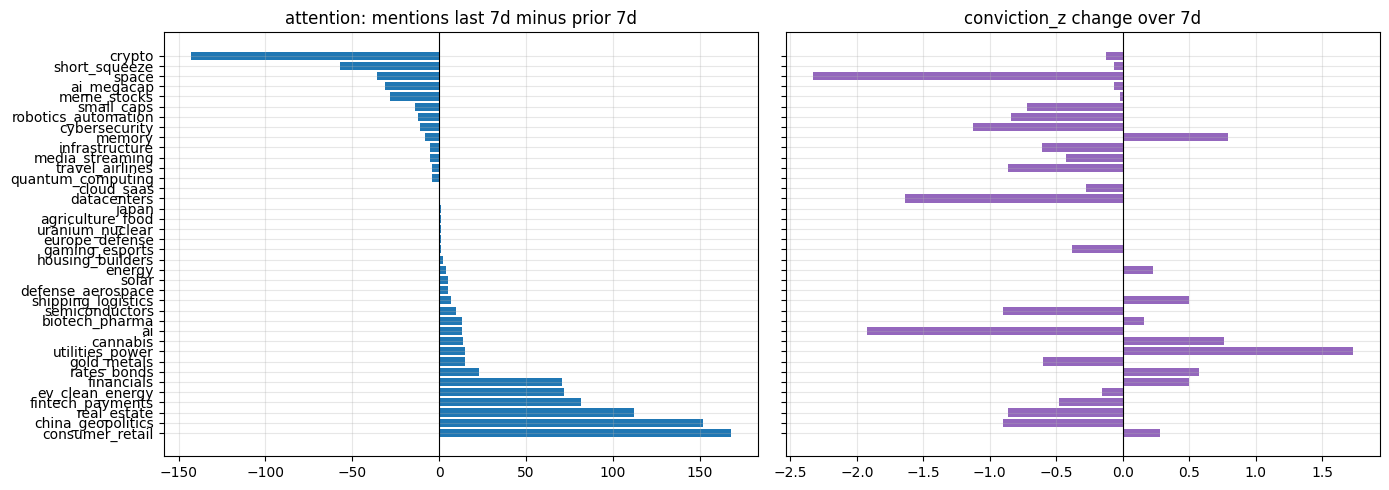

In [5]:
# ==== LIVE 1-WEEK LOOKBACK - the trading table ====
counts = pd.read_parquet(os.path.join(P, 'daily_theme_counts.parquet'))
# the aggregates carry 'mention_count'; older notebook-04 output carries
# keyword/inferred columns instead - handle both so this never breaks
if 'mention_count' not in counts.columns:
    counts['mention_count'] = (counts.get('keyword_count', 0)
                               + counts.get('inferred_count', 0))
counts['date'] = pd.to_datetime(counts['date'])
counts = clip_dates(counts, 'date')
end = counts['date'].max()

last7 = counts[counts['date'] > end - pd.Timedelta(days=7)]
prior7 = counts[(counts['date'] <= end - pd.Timedelta(days=7))
                & (counts['date'] > end - pd.Timedelta(days=14))]
tbl = pd.concat([
    last7.groupby('theme')['mention_count'].sum().rename('mentions_7d'),
    prior7.groupby('theme')['mention_count'].sum().rename('mentions_prior7d'),
], axis=1).fillna(0)
tbl['velocity_chg'] = tbl['mentions_7d'] - tbl['mentions_prior7d']

conv = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv['date'] = pd.to_datetime(conv['date'])
conv = clip_dates(conv, 'date')
latest = conv.sort_values('date').groupby('theme')['conviction_z'].last().rename('conv_now')
week_ago = (conv[conv['date'] <= end - pd.Timedelta(days=7)].sort_values('date')
            .groupby('theme')['conviction_z'].last().rename('conv_week_ago'))
tbl = tbl.join(latest).join(week_ago)
tbl['conv_chg_7d'] = tbl['conv_now'] - tbl['conv_week_ago']
tbl = tbl.sort_values('velocity_chg', ascending=False).round(2)

print(f'1-WEEK LOOKBACK (data through {end.date()}) - sorted by attention change')
print(tbl.to_string())

# visual: attention change vs conviction change, one bar pair per theme
plot = tbl.dropna(subset=['conv_chg_7d'])
if len(plot):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    ax1.barh(plot.index, plot['velocity_chg'], color='tab:blue')
    ax1.set_title('attention: mentions last 7d minus prior 7d')
    ax1.axvline(0, color='black', linewidth=0.8); ax1.grid(True, alpha=0.3)
    ax2.barh(plot.index, plot['conv_chg_7d'], color='tab:purple')
    ax2.set_title('conviction_z change over 7d')
    ax2.axvline(0, color='black', linewidth=0.8); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()
else:
    print('(not enough recent data for the chart - run update_data.py in LIVE mode first)')